# Laboratorio #7

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab7)

Para este laboratorio se trabajó con los datos de **@traficogt** en data.

> **Nota:** Se utilizó python 3.12.6 para compatibilidad con librerias.

## Librerias

In [165]:
# Separación de data y filtración
import json, os
import pandas as pd
import numpy as np

# Análisis exploratorio
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import folium
from folium.plugins import HeatMap
import seaborn as sns

# Limpieza lenguaje
import re, unicodedata
import spacy

nlp = spacy.load("es_core_news_sm")
STOP_ES = nlp.Defaults.stop_words

## Constantes


In [166]:
DATA_DIR = "data/"
DATA_FILE = DATA_DIR + "traficogt.txt"
DATA_CLEAN = DATA_DIR + "clean_traficogt.csv"

DATA_CLEAN_IN  = "data/clean_traficogt.csv"
DATA_CLEAN_OUT = "data/clean_traficogt_v2.csv"

DATA_USE = "data/clean_traficogt_v3"

In [ ]:
URL_RE   = re.compile(r"https://\S+")
EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u26FF]+")

## Sección 1

In [168]:
def processTweetsToCsv(input_path="data/traficogt.txt", output_path="data/clean_traficogt.csv"):
    """
    Lee tweets en formato JSONL (uno por línea), extrae campos específicos
    y escribe un CSV. Si un campo no existe o viene como null, se escribe 'null'
    en el CSV (usando na_rep='null').

    Columnas:
      tweet_id, date, user_id, username, followers_count, friends_count, statuses_count,
      raw_content, reply_count, retweet_count, like_count, quote_count, conversation_id,
      hashtags, mentioned_users, mentioned_users_ids, view_count, place, coordinates,
      in_reply_to_tweet_id, in_reply_to_user_id, in_reply_to_username,
      has_quote, quoted_tweet_id, quoted_user_id, quoted_username
    """

    # Detectar codificación simple (UTF-16 o UTF-8/UTF-8 BOM)
    enc = "utf-8"
    with open(input_path, "rb") as fb:
        sig = fb.read(4)
    if sig.startswith(b"\xff\xfe") or sig.startswith(b"\xfe\xff"):
        enc = "utf-16"
    elif sig.startswith(b"\xef\xbb\xbf"):
        enc = "utf-8-sig"

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    cols = [
        "tweet_id", "date", "user_id", "username",
        "followers_count", "friends_count", "statuses_count",
        "raw_content", "reply_count", "retweet_count", "like_count", "quote_count",
        "conversation_id", "hashtags", "mentioned_users", "mentioned_users_ids",
        "view_count", "place", "coordinates",
        "in_reply_to_tweet_id", "in_reply_to_user_id", "in_reply_to_username",
        "has_quote", "quoted_tweet_id", "quoted_user_id", "quoted_username"
    ]

    def extract_hashtags(hts):
        if not isinstance(hts, list):
            return ""
        out = []
        for h in hts:
            if isinstance(h, str):
                out.append(h)
            elif isinstance(h, dict):
                out.append(h.get("name") or h.get("text") or "")
        return ",".join([t for t in out if t])

    def extract_mentioned_users(mus):
        if not isinstance(mus, list):
            return ""
        out = []
        for u in mus:
            if isinstance(u, str):
                out.append(u)
            elif isinstance(u, dict):
                n = u.get("username") or u.get("screen_name") or ""
                if n:
                    out.append(n)
        return ",".join(out)

    def extract_mentioned_user_ids(mus):
        if not isinstance(mus, list):
            return ""
        out = []
        for u in mus:
            if isinstance(u, dict):
                mid = u.get("id")
                if mid is not None:
                    out.append(str(mid))
            elif isinstance(u, (int, str)):
                out.append(str(u))
        return ",".join(out)

    def serialize_obj(obj):
        # Para guardar 'place' o 'coordinates' como JSON en una sola celda
        if obj is None:
            return pd.NA
        if isinstance(obj, (dict, list)):
            return json.dumps(obj, ensure_ascii=False)
        return str(obj)

    rows = []
    with open(input_path, "r", encoding=enc) as f_in:
        for line in f_in:
            line = line.strip()
            if not line:
                continue
            try:
                tw = json.loads(line)
            except json.JSONDecodeError:
                continue

            user = tw.get("user") or {}
            in_reply_user = tw.get("inReplyToUser") or {}
            qt = tw.get("quotedTweet")

            # Manejo minimal de quote:
            has_quote = 0
            quoted_tweet_id = pd.NA
            quoted_user_id = pd.NA
            quoted_username = pd.NA
            if qt is not None:
                has_quote = 1
                if isinstance(qt, dict):
                    quoted_tweet_id = qt.get("id", pd.NA)
                    q_user = qt.get("user") or {}
                    quoted_user_id = q_user.get("id", pd.NA)
                    quoted_username = q_user.get("username", pd.NA)
                elif isinstance(qt, (int, str)):
                    quoted_tweet_id = qt  # si viene solo el id

            row = {
                "tweet_id": tw.get("id"),
                "date": tw.get("date"),
                "user_id": user.get("id"),
                "username": user.get("username"),
                "followers_count": user.get("followersCount"),
                "friends_count": user.get("friendsCount"),
                "statuses_count": user.get("statusesCount"),
                "raw_content": tw.get("rawContent"),
                "reply_count": tw.get("replyCount"),
                "retweet_count": tw.get("retweetCount"),
                "like_count": tw.get("likeCount"),
                "quote_count": tw.get("quoteCount"),
                "conversation_id": tw.get("conversationId"),
                "hashtags": extract_hashtags(tw.get("hashtags")),
                "mentioned_users": extract_mentioned_users(tw.get("mentionedUsers")),
                "mentioned_users_ids": extract_mentioned_user_ids(tw.get("mentionedUsers")),
                "view_count": tw.get("viewCount"),
                "place": serialize_obj(tw.get("place")),
                "coordinates": serialize_obj(tw.get("coordinates")),
                "in_reply_to_tweet_id": tw.get("inReplyToTweetId"),
                "in_reply_to_user_id": in_reply_user.get("id") if isinstance(in_reply_user, dict) else pd.NA,
                "in_reply_to_username": in_reply_user.get("username") if isinstance(in_reply_user, dict) else pd.NA,
                "has_quote": has_quote,
                "quoted_tweet_id": quoted_tweet_id,
                "quoted_user_id": quoted_user_id,
                "quoted_username": quoted_username,
            }

            # Convertir None explícitamente a pd.NA para que se exporte como 'null'
            for k, v in row.items():
                if v is None:
                    row[k] = pd.NA

            rows.append(row)

    df = pd.DataFrame(rows, columns=cols)
    df.to_csv(output_path, index=False, encoding="utf-8", na_rep="null")
    return {"output_csv": output_path, "rows": len(df)}

En el proceso de extracción de datos de los tweets, se seleccionaron 26 columnas del JSON original para preservar en el CSV, priorizando aquellas que contienen información clave para el análisis exploratorio y la construcción de redes.

### Idenficación del tweet

* **tweet_id**: ID único del tweet

  * Sirve para deduplicar, indexar y unir con otras tablas.

* **date**: fecha y hora UTC

  * Sirve para análisis de series temporales (picos por hora/día), relacionar con temporada de lluvias y cambios a lo largo del año.

### Autor (perfil del nodo)

* **user_id, username**: identifican al autor

  * Sirve para construir nodos de la red y etiquetar resultados.

* **followers_count, friends_count, statuses_count**: métricas del autor

  * Sirve para contexto de influencia potencial, comparar engagement relativo (p. ej., likes/followers).

### Contenido (texto y temas)

* **raw_content**: texto original

  * Sirve para tokenización, extracción de toponimia, tópicos y análisis de sentimiento (no mezclar con quoted).

* **hashtags**: lista de temas marcados

  * Sirve para identificar temas frecuentes y co-ocurrencias (wordclouds, top hashtags).

### Interacciones del tweet (engagement)

* **reply_count, retweet_count, like_count, quote_count, view_count**

  * Sirve para medir impacto y alcance, priorizar eventos relevantes y comparar periodos.

### Conversaciones e hilos

* **conversation_id**: agrupa tweets del mismo hilo

  * Sirve para reconstruir discusiones y detectar temas "calientes".

* **in_reply_to_tweet_id, in_reply_to_user_id, in_reply_to_username**: relaciones de respuesta

  * Sirve para construir aristas "reply" en la red (autor -> destinatario).

### Red de menciones

* **mentioned_users, mentioned_users_ids**: usuarios mencionados en el texto

  * Sirve para construir aristas "mention" (autor -> mencionados), detectar cuentas más aludidas y subredes temáticas.

### Ubicación (cuando exista o se infiera)

* **place, coordinates**: geotag oficial (suele ser null)

  * Sirve para mapeo directo; cuando es null, el `raw_content` permite inferir zonas/avenidas y luego unir a polígonos/centroides.

### Citas (quote)

* **has_quote** (0/1), **quoted_tweet_id, quoted_user_id, quoted_username**

  * Sirve para construir aristas "quote" (autor -> citado), identificar fuentes amplificadas y medir centralidad por citas.
  * Nota: el contenido del citado **no** se mezcla con el `raw_content` del autor; se usa solo para la red e influencia.

## Sección 2

In [169]:
def normalizeText(s: str) -> str:
    if pd.isna(s):
        return s
    s = str(s).lower()
    # quitar saltos de línea
    s = s.replace("\n", " ").replace("\r", " ")
    # quitar urls
    s = URL_RE.sub(" ", s)
    # quitar emojis
    s = EMOJI_RE.sub(" ", s)
    # quitar @ y #
    s = s.replace("@", " ").replace("#", " ")
    # quitar acentos
    s = ''.join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))
    # normalizar espacios
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [170]:
def applySection2_1() -> pd.DataFrame:
    # cargar csv
    df = pd.read_csv(DATA_CLEAN_IN)

    # aplicar a todas las columnas de texto
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(normalizeText)

    # guardar nuevo csv
    df.to_csv(DATA_CLEAN_OUT, index=False, encoding="utf-8")
    print({"rows_out": len(df), "output": DATA_CLEAN_OUT})
    
    return df

En la limpieza realizada se aplicaron las siguientes transformaciones sobre todas las columnas de texto del archivo:

1. **Conversión a minúsculas**: todo el contenido textual se pasó a minúsculas para uniformar la representación.
2. **Eliminación de saltos de línea**: los caracteres `\n` y `\r` se sustituyeron por espacios, evitando cortes dentro de un mismo campo.
3. **Eliminación de URLs**: se removieron los enlaces que inician con `https://`, evitando ruido en los textos.
4. **Eliminación de emojis**: se quitaron caracteres pertenecientes a los rangos Unicode de símbolos y emojis.
5. **Eliminación de arrobas y numerales**: se suprimieron los símbolos `@` y `#` en cualquier posición del texto.
6. **Eliminación de acentos**: se normalizaron los caracteres con tilde, de modo que `áéíóú` pasaron a `aeiou` y `ñ` a `n`.
7. **Normalización de espacios**: se redujeron múltiples espacios consecutivos a un solo espacio y se recortaron espacios al inicio y al final.

El resultado es un nuevo archivo CSV (`clean_traficogt_v2.csv`) con la misma estructura de columnas, pero con todos los campos de texto **limpios, uniformes y listos para análisis**.

In [171]:
def tokenize(text: str):
    doc = nlp(text)
    return [tok.text for tok in doc if tok.is_alpha]

def lemmatize(text: str):
    doc = nlp(text)
    return [tok.lemma_ for tok in doc if tok.is_alpha and tok.lemma_ not in STOP_ES]

In [172]:
def applySection2_2(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # normalizar todas las columnas de texto
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(normalizeText)
    
    # features de conteo
    df['exclaim_count']  = df['raw_content'].str.count(r"[!¡]")
    df['question_count'] = df['raw_content'].str.count(r"[?¿]")
    
    # tokenización y lematización
    df['tokens'] = df['raw_content'].apply(tokenize)
    df['lemmas'] = df['raw_content'].apply(lemmatize)
    
    # opcional: guardar CSV
    df.to_csv(DATA_USE, index=False, encoding="utf-8")
    print({"rows_out": len(df), "output": DATA_USE})
    
    return df


Después de aplicar esta limpieza y procesamiento de texto, obtendremos un DataFrame enriquecido con nuevas propiedades que permiten un análisis más profundo del contenido textual de los tweets. Específicamente, se generarán:

* **`exclaim_count`**: número de signos de exclamación (`!` o `¡`) en cada tweet, útil para analizar **énfasis o emoción**.
* **`question_count`**: número de signos de interrogación (`?` o `¿`) en cada tweet, útil para detectar **preguntas o curiosidad en el contenido**.
* **`tokens`**: lista de palabras individuales filtradas de caracteres no alfabéticos, que permite análisis de frecuencia, conteo de términos y generación de n-gramas.
* **`lemmas`**: lista de lemas de cada palabra, eliminando stopwords en español, lo que facilita tareas de análisis semántico, agrupación de palabras con la misma raíz y minería de tópicos.

## Sección 3

### Resumen general

In [173]:
def getDatasetSummary(df: pd.DataFrame) -> dict:
    return {
        "numTweets": len(df),
        "numUsers": df['user_id'].nunique(),
        "numHashtags": df['hashtags'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0).sum(),
        "numMentions": df['mentioned_users'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0).sum()
    }
    
def plotDatasetSummary(df: pd.DataFrame):
    summary = getDatasetSummary(df)
    keys = list(summary.keys())
    values = list(summary.values())
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=keys, y=values, hue=keys, palette="viridis", dodge=False, legend=False)
    plt.title("Resumen General del Dataset")
    plt.ylabel("Cantidad")
    plt.show()


### Conteo de interacciones

In [174]:
def getInteractionsSummary(df: pd.DataFrame) -> dict:
    return {
        "totalReplies": df['reply_count'].sum(),
        "totalRetweets": df['retweet_count'].sum(),
        "totalQuotes": df['quote_count'].sum(),
        "totalLikes": df['like_count'].sum()
    }
    
def plotInteractions(df: pd.DataFrame):
    interactions = getInteractionsSummary(df)
    keys = list(interactions.keys())
    values = list(interactions.values())
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=keys, y=values, hue=keys, palette="magma", dodge=False, legend=False)
    plt.title("Interacciones Totales de Tweets")
    plt.ylabel("Cantidad")
    plt.show()


### Hashtags más frecuentes y menciones

In [175]:
def getTopHashtags(df: pd.DataFrame, topN=10) -> list:
    hashtags = []
    for ht_list in df['hashtags'].dropna():
        hashtags.extend(ht_list.split(','))
    counter = Counter([ht.lower() for ht in hashtags if ht])
    return counter.most_common(topN)

def getTopMentionedUsers(df: pd.DataFrame, topN=10) -> list:
    mentions = []
    for mu_list in df['mentioned_users'].dropna():
        mentions.extend(mu_list.split(','))
    counter = Counter([mu.lower() for mu in mentions if mu])
    return counter.most_common(topN)

In [176]:
def plotTopHashtags(df: pd.DataFrame, topN=10):
    topHashtags = getTopHashtags(df, topN)
    labels, counts = zip(*topHashtags)
    
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(labels), hue=list(labels), palette="coolwarm", dodge=False, legend=False)
    plt.title(f"Top {topN} Hashtags")
    plt.xlabel("Frecuencia")
    plt.show()

def plotTopMentionedUsers(df: pd.DataFrame, topN=10):
    topUsers = getTopMentionedUsers(df, topN)
    labels, counts = zip(*topUsers)
    
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(labels), hue=list(labels), palette="Set2", dodge=False, legend=False)
    plt.title(f"Top {topN} Usuarios Mencionados")
    plt.xlabel("Frecuencia")
    plt.show()


### Tweets por hora

In [ ]:
def getTweetsByHour(df: pd.DataFrame) -> pd.Series:
    df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce').dt.tz_convert('America/Guatemala')
    return df.groupby(df['date'].dt.hour).size()

def getTopTweetHours(df: pd.DataFrame, topN=5) -> list:
    df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce').dt.tz_convert('America/Guatemala')
    counts = df.groupby(df['date'].dt.hour).size()
    return counts.sort_values(ascending=False).head(topN).to_dict()

def plotTweetsByHour(df: pd.DataFrame):
    tweetsByHour = getTweetsByHour(df)
    plt.figure(figsize=(12,5))
    sns.barplot(x=tweetsByHour.index, y=tweetsByHour.values, hue=tweetsByHour.index, palette="viridis", dodge=False, legend=False)
    plt.title("Distribución de Tweets por Hora")
    plt.xlabel("Hora del día")
    plt.ylabel("Número de tweets")
    plt.show()

### Flujo completo

In [178]:
def generateWordCloud(df: pd.DataFrame, column='lemmas', maxWords=100):
    text = ' '.join([' '.join(t) if isinstance(t, list) else str(t) for t in df[column].dropna()])
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=maxWords).generate(text)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [179]:
def exploratoryTrafficAnalysis(df: pd.DataFrame):
    print("=== Resumen General ===")
    summary = getDatasetSummary(df)
    print(summary)
    
    print("\n=== Interacciones ===")
    interactions = getInteractionsSummary(df)
    print(interactions)
    
    print("\n=== Hashtags Más Frecuentes ===")
    topHashtags = getTopHashtags(df)
    print(topHashtags)
    
    print("\n=== Usuarios Más Mencionados ===")
    topUsers = getTopMentionedUsers(df)
    print(topUsers)
    
    print("\n=== Distribución de Tweets por Hora ===")
    tweetsByHour = getTweetsByHour(df)
    print(tweetsByHour)

In [180]:
def exploratoryTrafficAnalysisVisual(df: pd.DataFrame):
    # 1) Resumen
    plotDatasetSummary(df)
    
    # 2) Interacciones
    plotInteractions(df)
    
    # 3) Hashtags top
    plotTopHashtags(df)
    
    # 4) Usuarios mencionados top
    plotTopMentionedUsers(df)
    
    # 5) Tweets por hora
    plotTweetsByHour(df)
    
    # 6) Nube de palabras
    print("=== Nube de Palabras (Lemas) ===")
    generateWordCloud(df, column='lemmas')

## Sección 4

## Pipeline

In [181]:
processTweetsToCsv(input_path=DATA_FILE, output_path=DATA_CLEAN)
data_clean1 = applySection2_1()
data_clean2 = applySection2_2(df=data_clean1)

{'rows_out': 5604, 'output': 'data/clean_traficogt_v2.csv'}
{'rows_out': 5604, 'output': 'data/clean_traficogt_v3'}


In [182]:
exploratoryTrafficAnalysis(df=data_clean2)

=== Resumen General ===
{'numTweets': 5604, 'numUsers': 2071, 'numHashtags': np.int64(578), 'numMentions': np.int64(10929)}

=== Interacciones ===
{'totalReplies': np.int64(74022), 'totalRetweets': np.int64(168891), 'totalQuotes': np.int64(34902), 'totalLikes': np.int64(483690)}

=== Hashtags Más Frecuentes ===
[('ahora', 30), ('guatemala', 25), ('ahoralh', 19), ('traficogt', 18), ('urgente', 16), ('renunciengolpistas', 15), ('trafico', 9), ('paronacionalindefinido', 9), ('lahoradeactualizarnos', 8), ('guateresiste', 8)]

=== Usuarios Más Mencionados ===
[('traficogt', 4243), ('barevalodeleon', 432), ('drgiammattei', 174), ('amilcarmontejo', 166), ('prensacomunitar', 162), ('mpguatemala', 138), ('mmendoza_gt', 132), ('lahoragt', 128), ('cc_guatemala', 110), ('muniguate', 99)]

=== Distribución de Tweets por Hora ===
date
0      65
1      37
2      12
3      16
4      13
5      41
6     146
7     312
8     323
9     259
10    250
11    269
12    319
13    389
14    387
15    343
16    3

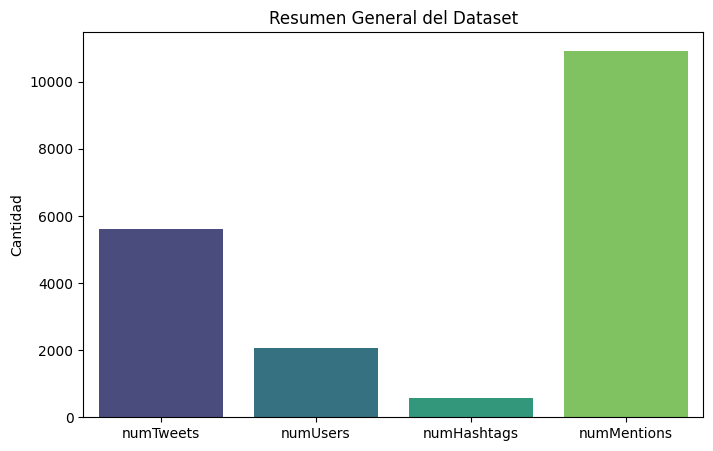

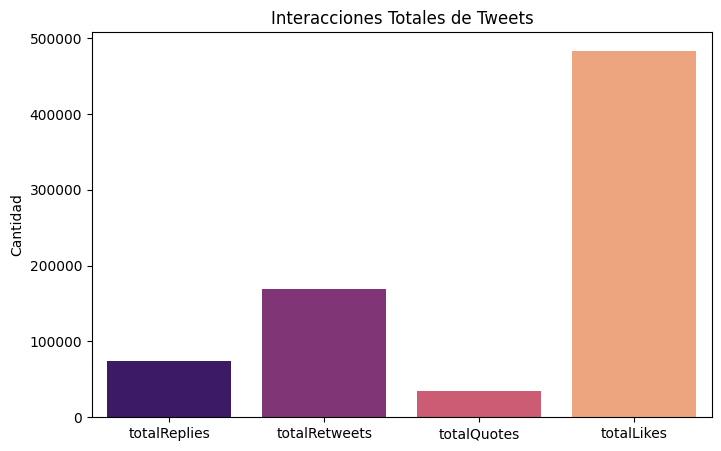

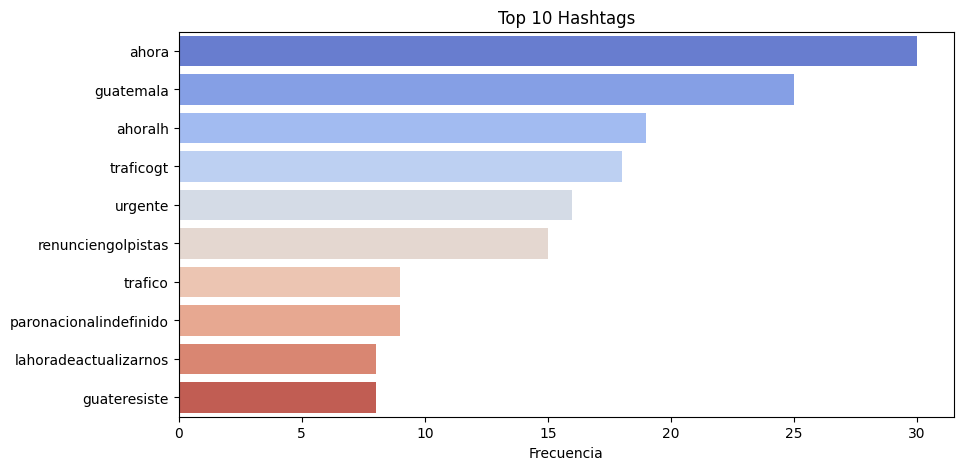

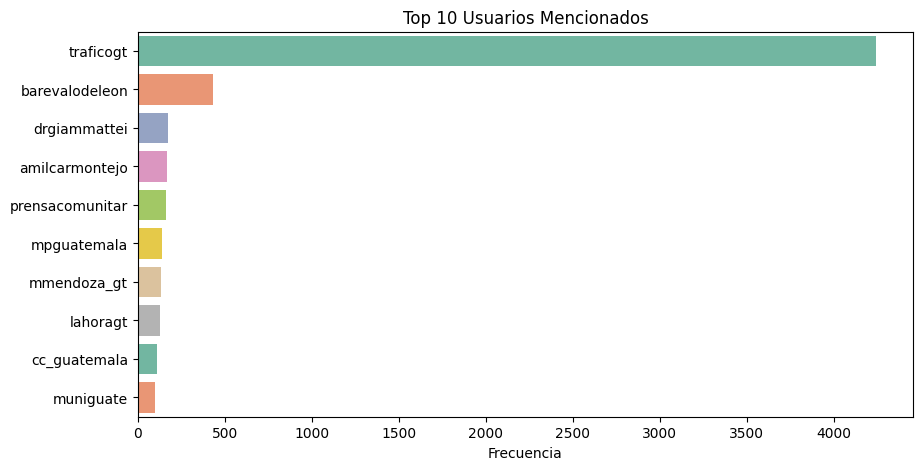

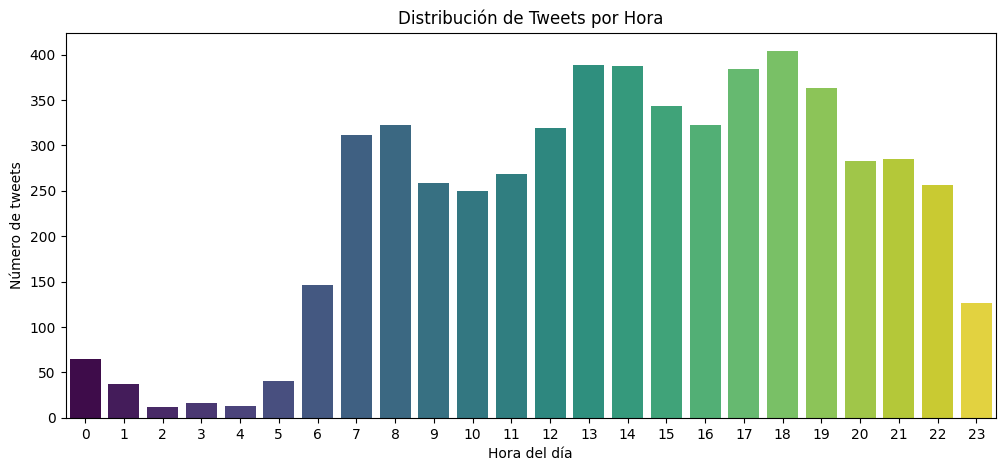

=== Nube de Palabras (Lemas) ===


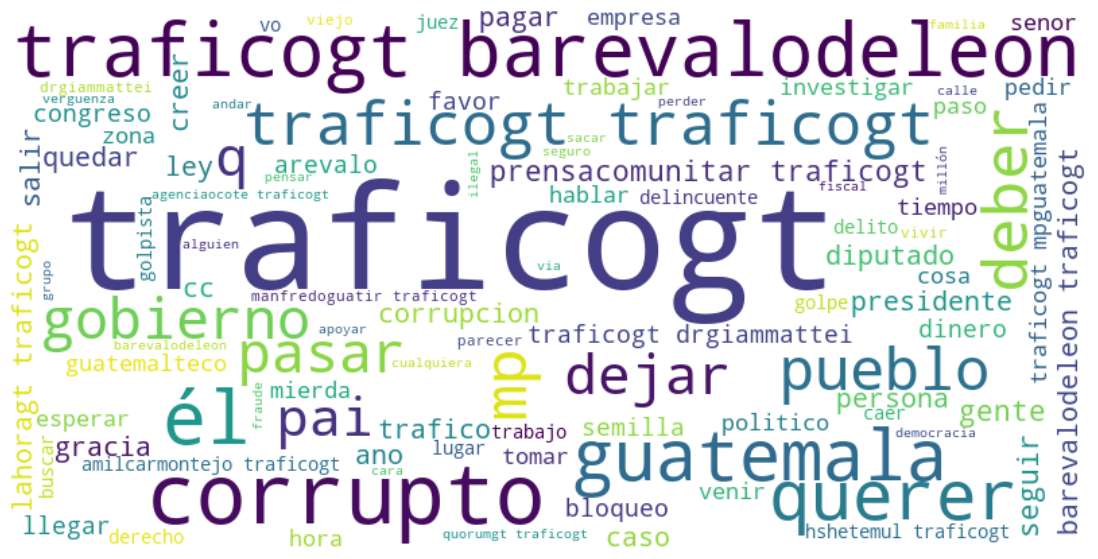

In [183]:
exploratoryTrafficAnalysisVisual(df=data_clean2)

### Volumen y usuarios

* **Tweets totales:** 5,604 de **2,071** usuarios -> **2.71** tweets/usuario en promedio.
  
    *Base:* `numTweets`, `numUsers`.

* **Menciones:** 10,929 -> **1.95** menciones por tweet.
  
    *Base:* `numMentions/numTweets`.

### Interacciones

* **Interacciones totales:** 761,505 -> **135.9** por tweet.
  
    *Base:* suma (replies+RT+quotes+likes)/5,604.

* Composición de interacciones: **Likes 63.5%**, **RT 22.2%**, **Replies 9.7%**, **Quotes 4.6%**.
  
    *Base:* 483,690; 168,891; 74,022; 34,902.

### Hashtags y menciones

* **Top 10 hashtags** suman **27.2%** de todos los hashtags (157/578) -> dispersión alta; el uso de hashtag es bajo (**0.10** por tweet).
  
    *Base:* `numHashtags=578`, top10=157.

* **Nodo central:** `@traficogt` concentra **38.8%** de todas las menciones (4,243/10,929).
  
    *Base:* Top menciones.

* **Concentración:** Top 10 usuarios mencionados = **52.9%** de menciones.
    
    *Base:* 5,784/10,929.

### Horas con más actividad (GT)

* **18:00**: 404 (**7.21%**)
* **13:00**: 389 (**6.94%**)
* **14:00**: 387 (**6.91%**)
* **17:00**: 384 (**6.85%**)
* **19:00**: 363 (**6.48%**)
  
  Estas 5 horas concentran **34.39%** del total (1,927/5,604).
  
  Por franjas: **Tarde 12–17 = 38.26%**, **Noche 18–23 = 30.64%**, **Mañana 06–11 = 27.82%**, **Madrugada 00–05 = 3.28%**.
  
  Pico 18:00 (404) vs mínimo 02:00 (12) ⇒ **33.7×** más; vs la **mediana/hora (276)** el pico está **+46.4%**.

### Temas

* Nube de palabras y hashtags mezclan tráfico (*trafico, traficogt*) algo relacionado a política (*guatemala, renunciengolpistas, paronacionalindefinido*).
  
    *Base:* Top hashtags y wordcloud.